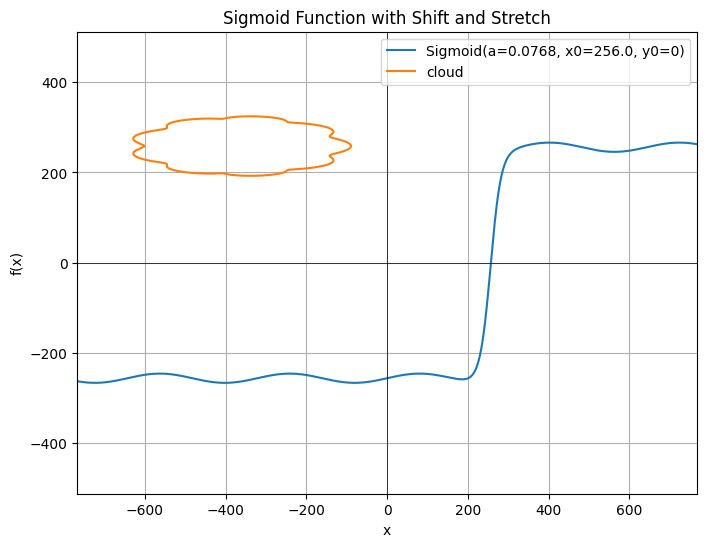

In [97]:
import numpy as np
import matplotlib.pyplot as plt


width = 256*3
height = 256*2
# 生成 x 轴的数据
x = np.linspace(-width, width, 1000)

# 设置不同的参数
a = width/10000    # 拉伸因子，控制函数的陡峭度
x0 = width/3   # 水平平移，控制函数在 x 轴的位置
y0 = 0   # 垂直平移，控制函数在 y 轴的位置

# 生成参数 t，从 0 到 2π
t = np.linspace(0, 2 * np.pi, 1000)
# 使用参数化方程计算椭圆的 x 和 y 坐标
cloud_x = width/3 * np.cos(t) - width/2 + width/40 * (np.cos(10*t)+1)
cloud_y = height/8 * np.sin(t) + height/2 + height/200 * (np.sin(10*t)+1)

# 计算 Sigmoid 函数值
y = height / (1 + np.exp(-a * (x - x0))) - height + height/2 + height/50*np.sin(15/width*x)

# 绘制 Sigmoid 函数图像
plt.figure(figsize=(8, 6))
plt.plot(x, y, label=f'Sigmoid(a={a}, x0={x0}, y0={y0})')
plt.plot(cloud_x, cloud_y, label='cloud')
plt.title('Sigmoid Function with Shift and Stretch')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.xlim(-width, width)
plt.ylim(-height,height)
plt.grid(True)
plt.legend()
plt.show()

In [58]:
from matplotlib.path import Path
from matplotlib.colors import ListedColormap, BoundaryNorm

# 画布尺寸与坐标范围
width = 256 * 3
height = 256 * 2
cols = width * 2
rows = height * 2

x_vals = np.linspace(-width, width, cols)
y_vals = np.linspace(-height, height, rows)
X, Y = np.meshgrid(x_vals, y_vals)

a = width / 10000
x0 = width / 3
t = np.linspace(0, 2 * np.pi, 1000)
cloud_x = width / 3 * np.cos(t) - width / 2 + width / 40 * (np.cos(10 * t) + 1)
cloud_y = height / 8 * np.sin(t) + height / 2 + height / 200 * (np.sin(10 * t) + 1)

sigmoid_y = height / (1 + np.exp(-a * (x_vals - x0))) - height + height / 2 + height / 50 * np.sin(15 / width * x_vals)

canvas = np.zeros((rows, cols), dtype=np.uint8)
canvas[Y <= sigmoid_y] = 1

polygon = Path(np.column_stack((cloud_x, cloud_y)))
points = np.column_stack((X.ravel(), Y.ravel()))
cloud_mask = polygon.contains_points(points).reshape(rows, cols)
canvas[cloud_mask] = 2

np.savetxt('cloud_scene.csv', canvas, fmt='%d', delimiter=',')

loaded = np.loadtxt('cloud_scene.csv', delimiter=',', dtype=int)
cmap = ListedColormap(['blue', 'green', 'white'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], cmap.N)

plt.figure(figsize=(10, 6))
plt.imshow(loaded, cmap=cmap, norm=norm, origin='lower', extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()])
plt.colorbar(ticks=[0, 1, 2], label='Class')
plt.title('Segmented Cloud Scene')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

ERROR: unknown command "package"


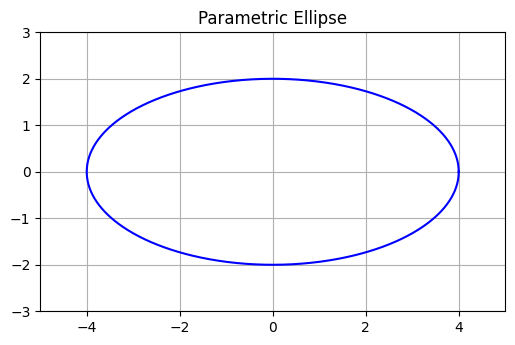

In [41]:
import numpy as np
import matplotlib.pyplot as plt

# 设置椭圆参数
a = 4  # 长半轴
b = 2  # 短半轴
h = 0  # 中心x坐标
k = 0  # 中心y坐标

# 生成参数 t，从 0 到 2π
t = np.linspace(0, 2 * np.pi, 1000)

# 使用参数化方程计算椭圆的 x 和 y 坐标
x = a * np.cos(t) + h
y = b * np.sin(t) + k

# 绘制椭圆
plt.figure(figsize=(6, 6))
plt.plot(x, y, label="Ellipse", color="blue")

# 设置坐标轴范围，确保椭圆完整显示
plt.xlim(-a-1, a+1)
plt.ylim(-b-1, b+1)

# 设置图形的比例，使得椭圆看起来不变形
plt.gca().set_aspect('equal', adjustable='box')

# 添加标题
plt.title("Parametric Ellipse")

# 显示图形
plt.grid(True)
plt.show()
